# CellOT OOD Evaluation: Cross-Species Perturbation Prediction

**Goal**: Evaluate how well CellOT predicts perturbation responses for the held-out **rat** species (OOD setting).

Two models are compared:
1. **CellOT-50dim** — trained in 50-dim scGen latent space (race_cpu, 10k iters)
2. **CellOT-1000dim** — trained directly on 1000-dim raw gene expression (cross_species_ood, 100k iters)

### Evaluation runs

| Eval | Model | `--where` | `--embedding` | Metrics available |
|------|-------|-----------|---------------|-------------------|
| **Primary** | CellOT-50dim | `latent_space` | — | MMD, KNN enrichment, l2/r2 correlations |
| Side | CellOT-50dim | `data_space` | `ae` | l2/r2 correlations (decoded to 1000-dim) |
| Side | CellOT-1000dim | `data_space` | — | l2/r2 correlations (native 1000-dim) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

BASE = '/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot'

EVAL_PATHS = {
    'CellOT-50dim (latent_space)': f'{BASE}/cellot_gpu/results/race_cpu/evals_ood_latent_space/evals.csv',
    'CellOT-50dim (data_space)':   f'{BASE}/cellot_gpu/results/race_cpu/evals_ood_data_space/evals.csv',
    'CellOT-1000dim (data_space)': f'{BASE}/cellot/results/cross_species_ood/evals_ood_data_space/evals.csv',
}

evals = {}
for label, path in EVAL_PATHS.items():
    if os.path.exists(path):
        evals[label] = pd.read_csv(path)
        print(f'{label}: {len(evals[label])} rows, metrics: {sorted(evals[label]["metric"].unique())}')
    else:
        print(f'{label}: NOT READY YET ({path})')

CellOT-50dim (latent_space): 450 rows, metrics: ['enrichment-k100', 'enrichment-k50', 'l2-means', 'l2-pairwise_feat_corrs', 'l2-stds', 'mmd', 'r2-means', 'r2-pairwise_feat_corrs', 'r2-stds']
CellOT-50dim (data_space): NOT READY YET (/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/race_cpu/evals_ood_data_space/evals.csv)
CellOT-1000dim (data_space): NOT READY YET (/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot/results/cross_species_ood/evals_ood_data_space/evals.csv)


## 1. Primary Analysis: CellOT-50dim OOD Performance (Latent Space)

This is the standard CellOT evaluation for scRNA-seq. The model was trained in 50-dim scGen
latent space and evaluated there. All metrics including MMD and KNN enrichment are available.

In [9]:
key = 'CellOT-50dim (latent_space)'
if key not in evals:
    raise RuntimeError(f'{key} not loaded — rerun after job completes')

df = evals[key]
metrics = df['metric'].unique()
ncells_vals = sorted(df['ncells'].unique())

summary = (
    df.groupby(['ncells', 'metric'])['value']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

print('=== CellOT-50dim OOD Evaluation Summary (latent space) ===')
print(f'Cell subsample sizes: {ncells_vals}')
print(f'Reps per size: {int(summary["count"].iloc[0])}')
print(f'Metrics: {list(metrics)}\n')

for m in metrics:
    sub = summary[summary['metric'] == m]
    vals = ', '.join([f'n={int(r.ncells)}: {r["mean"]:.4f} ± {r["std"]:.4f}' for _, r in sub.iterrows()])
    print(f'  {m}: {vals}')

=== CellOT-50dim OOD Evaluation Summary (latent space) ===
Cell subsample sizes: [100, 250, 500, 1000, 1500]
Reps per size: 10
Metrics: ['l2-means', 'l2-stds', 'r2-means', 'r2-stds', 'r2-pairwise_feat_corrs', 'l2-pairwise_feat_corrs', 'mmd', 'enrichment-k50', 'enrichment-k100']

  l2-means: n=100: 19.5672 ± 0.3150, n=250: 19.4411 ± 0.1717, n=500: 19.4064 ± 0.1210, n=1000: 19.4156 ± 0.0693, n=1500: 19.4155 ± 0.0527
  l2-stds: n=100: 2.2385 ± 0.2379, n=250: 2.1684 ± 0.1690, n=500: 2.1346 ± 0.0952, n=1000: 2.1108 ± 0.0727, n=1500: 2.0647 ± 0.0316
  r2-means: n=100: 0.8431 ± 0.0052, n=250: 0.8461 ± 0.0021, n=500: 0.8456 ± 0.0017, n=1000: 0.8457 ± 0.0009, n=1500: 0.8457 ± 0.0010
  r2-stds: n=100: 0.7828 ± 0.0398, n=250: 0.7946 ± 0.0294, n=500: 0.8013 ± 0.0109, n=1000: 0.8080 ± 0.0106, n=1500: 0.8150 ± 0.0077
  r2-pairwise_feat_corrs: n=100: 0.6864 ± 0.0343, n=250: 0.7089 ± 0.0161, n=500: 0.7276 ± 0.0090, n=1000: 0.7381 ± 0.0091, n=1500: 0.7404 ± 0.0053
  l2-pairwise_feat_corrs: n=100: 9.691

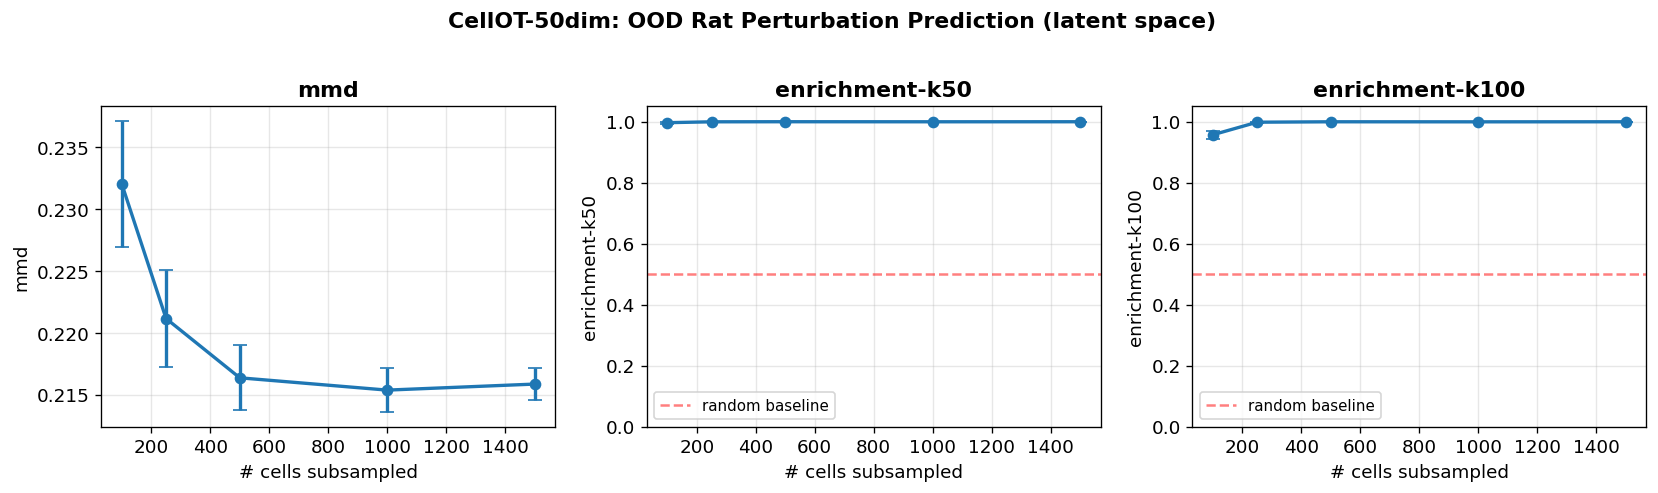

In [3]:
# Distributional metrics: MMD and KNN enrichment across cell subsample sizes
dist_metrics = ['mmd', 'enrichment-k50', 'enrichment-k100']
dist_df = summary[summary['metric'].isin(dist_metrics)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, m in zip(axes, dist_metrics):
    sub = dist_df[dist_df['metric'] == m]
    ax.errorbar(sub['ncells'], sub['mean'], yerr=sub['std'], marker='o', capsize=4, linewidth=2)
    ax.set_xlabel('# cells subsampled')
    ax.set_ylabel(m)
    ax.set_title(m, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if 'enrichment' in m:
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random baseline')
        ax.legend(fontsize=9)

fig.suptitle('CellOT-50dim: OOD Rat Perturbation Prediction (latent space)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/ood_distributional_metrics.png',
            bbox_inches='tight', dpi=150)
plt.show()

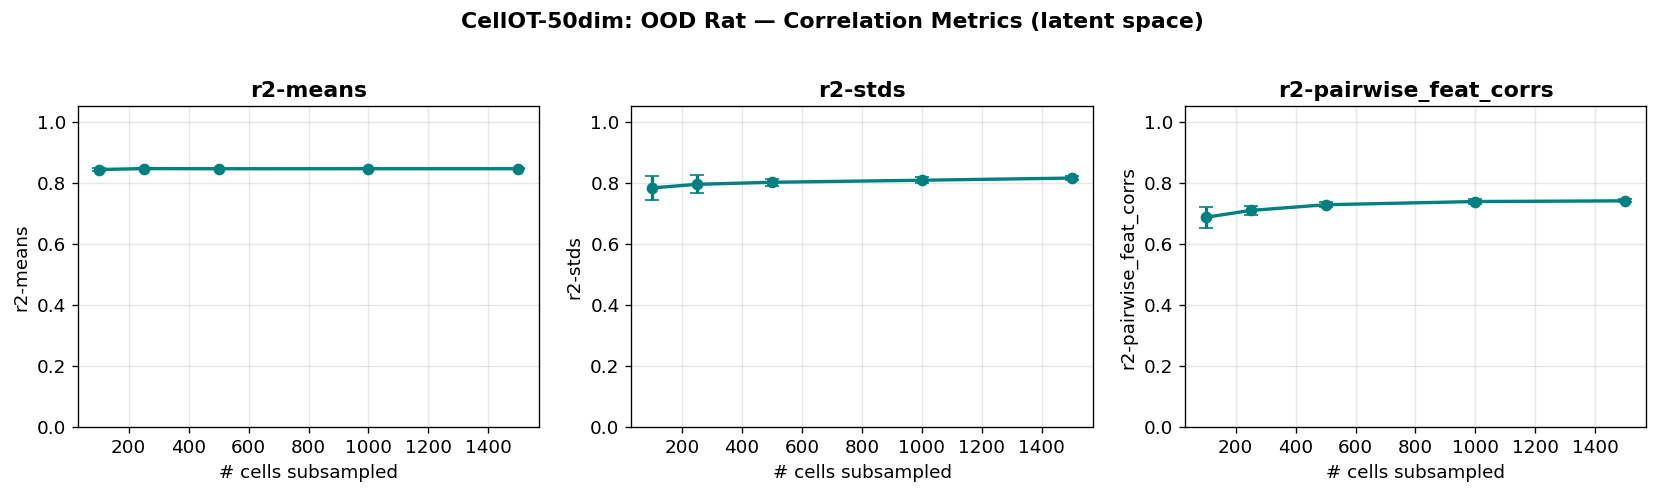

In [4]:
# Correlation metrics across cell subsample sizes
corr_metrics = ['r2-means', 'r2-stds', 'r2-pairwise_feat_corrs']
corr_df = summary[summary['metric'].isin(corr_metrics)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, m in zip(axes, corr_metrics):
    sub = corr_df[corr_df['metric'] == m]
    ax.errorbar(sub['ncells'], sub['mean'], yerr=sub['std'], marker='o', capsize=4, linewidth=2, color='teal')
    ax.set_xlabel('# cells subsampled')
    ax.set_ylabel(m)
    ax.set_title(m, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

fig.suptitle('CellOT-50dim: OOD Rat — Correlation Metrics (latent space)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/ood_correlation_metrics_latent.png',
            bbox_inches='tight', dpi=150)
plt.show()

### Interpretation Guide

**MMD** (Maximum Mean Discrepancy): Lower is better. Measures how close the predicted
perturbation distribution is to the true held-out rat perturbation distribution.

**KNN Enrichment (k50, k100)**: Fraction of k-nearest neighbors of a predicted cell
that are also predicted (vs truly treated). Values near 1.0 mean predicted and treated
cells are well-mixed; near 0.5 means they are indistinguishable (ideal).
- **~1.0**: predicted cells cluster with each other (poor mixing)
- **~0.5**: predicted and real treated cells are indistinguishable (perfect)

**r2-means**: Pearson correlation between mean gene expression of predicted vs true
treated cells. Higher is better. Measures whether the model captures the average
perturbation effect direction.

**r2-stds**: Pearson correlation of per-gene standard deviations. Captures whether the
model reproduces the correct variability structure.

**r2-pairwise_feat_corrs**: Correlation of gene-gene correlation matrices. Tests whether
the model preserves the co-expression structure.

## 2. Side Analysis: CellOT-50dim vs CellOT-1000dim in Data Space

Both models evaluated in the original 1000-dim gene expression space.
- CellOT-50dim: output decoded back to 1000-dim via frozen scGen decoder
- CellOT-1000dim: native 1000-dim output

Only l2/r2 correlation metrics available here (MMD skipped when features >= 1000).

In [5]:
ds_keys = ['CellOT-50dim (data_space)', 'CellOT-1000dim (data_space)']
ds_available = {k: evals[k] for k in ds_keys if k in evals}

if len(ds_available) < 2:
    missing = [k for k in ds_keys if k not in evals]
    print(f'Waiting for: {missing}')
    print('Re-run this cell once those evaluation jobs complete.')
else:
    ds_summaries = {}
    for label, df in ds_available.items():
        ds_summaries[label] = (
            df.groupby(['ncells', 'metric'])['value']
            .agg(['mean', 'std'])
            .reset_index()
        )

    compare_metrics = ['r2-means', 'r2-stds', 'r2-pairwise_feat_corrs',
                       'l2-means', 'l2-stds', 'l2-pairwise_feat_corrs']

    print('=== Data-Space Comparison (1000-dim gene expression) ===')
    print('Using largest cell subsample for summary:\n')

    max_ncells = max(ds_summaries[ds_keys[0]]['ncells'])

    rows = []
    for m in compare_metrics:
        row = {'metric': m}
        for label, summ in ds_summaries.items():
            sub = summ[(summ['metric'] == m) & (summ['ncells'] == max_ncells)]
            if len(sub) > 0:
                row[label] = f"{sub['mean'].iloc[0]:.4f} ± {sub['std'].iloc[0]:.4f}"
            else:
                row[label] = 'N/A'
        rows.append(row)

    compare_df = pd.DataFrame(rows).set_index('metric')
    display(compare_df)

Waiting for: ['CellOT-50dim (data_space)', 'CellOT-1000dim (data_space)']
Re-run this cell once those evaluation jobs complete.


In [6]:
if len(ds_available) >= 2:
    r2_metrics = ['r2-means', 'r2-stds', 'r2-pairwise_feat_corrs']
    colors = {'CellOT-50dim (data_space)': 'steelblue', 'CellOT-1000dim (data_space)': 'coral'}

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, m in zip(axes, r2_metrics):
        for label, summ in ds_summaries.items():
            sub = summ[summ['metric'] == m]
            short_label = label.split('(')[0].strip()
            ax.errorbar(sub['ncells'], sub['mean'], yerr=sub['std'],
                        marker='o', capsize=4, linewidth=2,
                        color=colors[label], label=short_label)
        ax.set_xlabel('# cells subsampled')
        ax.set_ylabel(m)
        ax.set_title(m, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    fig.suptitle('Data-Space (1000-dim) Comparison: OOD Rat Perturbation', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/ood_dataspace_comparison.png',
                bbox_inches='tight', dpi=150)
    plt.show()

In [7]:
if len(ds_available) >= 2:
    l2_metrics = ['l2-means', 'l2-stds', 'l2-pairwise_feat_corrs']

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, m in zip(axes, l2_metrics):
        for label, summ in ds_summaries.items():
            sub = summ[summ['metric'] == m]
            short_label = label.split('(')[0].strip()
            ax.errorbar(sub['ncells'], sub['mean'], yerr=sub['std'],
                        marker='o', capsize=4, linewidth=2,
                        color=colors[label], label=short_label)
        ax.set_xlabel('# cells subsampled')
        ax.set_ylabel(m)
        ax.set_title(f'{m} (lower is better)', fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    fig.suptitle('Data-Space (1000-dim) L2 Distances: OOD Rat Perturbation', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/analysis/ood_dataspace_l2_comparison.png',
                bbox_inches='tight', dpi=150)
    plt.show()

## 3. Combined Summary Table

All metrics across both evaluation spaces, at the largest cell subsample size.

In [8]:
all_metrics = ['mmd', 'enrichment-k50', 'enrichment-k100',
               'r2-means', 'r2-stds', 'r2-pairwise_feat_corrs',
               'l2-means', 'l2-stds', 'l2-pairwise_feat_corrs']

all_summaries = {}
for label, df in evals.items():
    all_summaries[label] = (
        df.groupby(['ncells', 'metric'])['value']
        .agg(['mean', 'std'])
        .reset_index()
    )

max_n = {}
for label, summ in all_summaries.items():
    max_n[label] = summ['ncells'].max()

rows = []
for m in all_metrics:
    row = {'metric': m}
    for label, summ in all_summaries.items():
        sub = summ[(summ['metric'] == m) & (summ['ncells'] == max_n[label])]
        if len(sub) > 0:
            row[label] = f"{sub['mean'].iloc[0]:.4f} ± {sub['std'].iloc[0]:.4f}"
        else:
            row[label] = '—'
    rows.append(row)

final_table = pd.DataFrame(rows).set_index('metric')
print(f'Metrics at largest available n_cells per evaluation:\n')
display(final_table)

Metrics at largest available n_cells per evaluation:



,CellOT-50dim (latent_space)
metric,
mmd,0.2159 ± 0.0013
enrichment-k50,0.9997 ± 0.0002
enrichment-k100,0.9996 ± 0.0002
r2-means,0.8457 ± 0.0010
r2-stds,0.8150 ± 0.0077
r2-pairwise_feat_corrs,0.7404 ± 0.0053
l2-means,19.4155 ± 0.0527
l2-stds,2.0647 ± 0.0316
l2-pairwise_feat_corrs,8.4675 ± 0.1065


## 4. Key Takeaways

Fill in after inspecting the results above:

- **MMD (50-dim latent)**: _How well does CellOT-50dim predict the rat perturbation distribution?_
- **KNN enrichment**: _Are predicted and real treated cells well-mixed?_ Values near 0.5 = ideal; near 1.0 = poor.
- **r2-means (data space)**: _Does the scGen→CellOT pipeline preserve mean perturbation direction in gene expression space?_
- **50dim vs 1000dim**: _Does dimensionality reduction via scGen help or hurt OOD generalization?_